In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


In [26]:
from google.colab import drive

In [27]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Titanic-Dataset.csv')

In [29]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [30]:
print('=== Dataset Info ===')
df.info

=== Dataset Info ===


<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ...    ...   
886                              Montvila, Rev. Juozas    male  27.0      0   
887                       Graham, Miss. Margaret Edith  female  19.0      0   
888           Johnston, Miss. Catherine Helen "Carrie"  female   NaN      1   
889                              Behr, Mr. Karl Howell    male  26.0      0   
890                                Dooley, Mr. Patrick    male  32.0      0   

     Parch            Ticket     Fare Cabin Embarked  
0        0         A/5 21171   7.2500   NaN        S  
1        0          PC 17599  71.2833   C85        C  
2        0  STON/O2. 3101282   7.9250   NaN        S  
3        0            113803  53.1000  C123        S  
4        0            373450   8.0500   NaN        S  
..     ...               ...      ...   ...      ...  
886      0            211536  13.0000   NaN        S  
887      0            112053  30.0000   B42        S  
888      2        W./C. 6607  23.4500   NaN        S  
889      0            111369  30.0000  C148        C  
890      0            370376   7.7500   NaN        Q  

[891 rows x 12 columns]>

In [31]:
print('=== Statistical Summary ===')
df.describe()

=== Statistical Summary ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [32]:
print('=== Missing Values ===')
print(df.isnull().sum())

=== Missing Values ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


=== Target Class Distribution ===
Survived
0    549
1    342
Name: count, dtype: int64


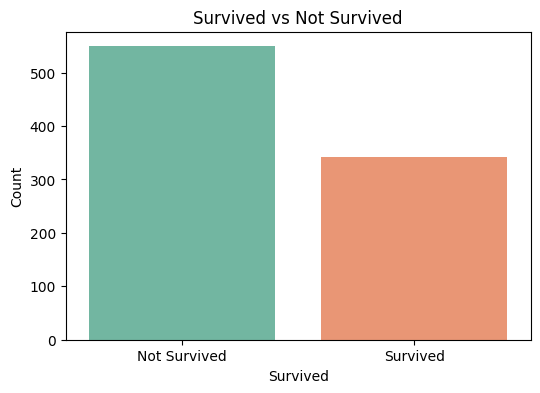

In [33]:
print('=== Target Class Distribution ===')
print(df['Survived'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df, palette='Set2')

plt.title('Survived vs Not Survived')
plt.xticks([0,1], ['Not Survived', 'Survived'])
plt.ylabel('Count')

plt.show()

In [34]:
df = df[['Survived', 'Pclass', 'Sex', 'Age',
         'SibSp', 'Parch', 'Fare', 'Embarked']]

print('Selected columns:', df.columns.tolist())
print('Shape:', df.shape)

Selected columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Shape: (891, 8)


In [35]:
# --- Handle Missing Values ---

# Age: fill with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Embarked: fill with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

print('Missing values after handling:')
print(df.isnull().sum())

Missing values after handling:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [36]:
# --- Encode Categorical Features ---

# sex: male=1, female=0
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])

# embarked: S=2, Q=1, C=0
df['Embarked'] = LabelEncoder().fit_transform(df['Embarked'])

print('After encoding:')
df.head()

After encoding:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [37]:
# --- Features and Target ---
X = df.drop('Survived', axis=1)
y = df['Survived']

print('Feature shape:', X.shape)
print('Target shape:', y.shape)

Feature shape: (891, 7)
Target shape: (891,)


In [38]:
# --- Normalize/Standardize Numerical Features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features standardized successfully!')
print('Mean (should be ~0):', X_scaled.mean(axis=0).round(2))

Features standardized successfully!
Mean (should be ~0): [-0. -0.  0.  0.  0.  0. -0.]


In [39]:
# --- Split into Train / Validation / Test ---

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 75% train, 25% validation (from the 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f'Train size:      {X_train.shape[0]} samples (60%)')
print(f'Validation size: {X_val.shape[0]} samples (20%)')
print(f'Test size:       {X_test.shape[0]} samples (20%)')

Train size:      534 samples (60%)
Validation size: 178 samples (20%)
Test size:       179 samples (20%)


In [40]:
# --- Train Logistic Regression Model ---
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print('Model trained successfully!')

Model trained successfully!


In [41]:
# --- Validation Set Performance ---
y_val_pred = model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f'Validation Accuracy: {val_accuracy:.4f}')

Validation Accuracy: 0.7921


In [42]:
# --- Test Set Predictions ---
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability scores

# --- Calculate All Metrics ---
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_prob)

print('='*40)
print('       EVALUATION METRICS (Test Set)')
print('='*40)
print(f'  Accuracy  : {accuracy:.4f}')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  AUC       : {auc:.4f}')
print('='*40)
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

       EVALUATION METRICS (Test Set)
  Accuracy  : 0.7877
  Precision : 0.7541
  Recall    : 0.6667
  F1-Score  : 0.7077
  AUC       : 0.8473

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.81      0.86      0.83       110
    Survived       0.75      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.79      0.79      0.78       179



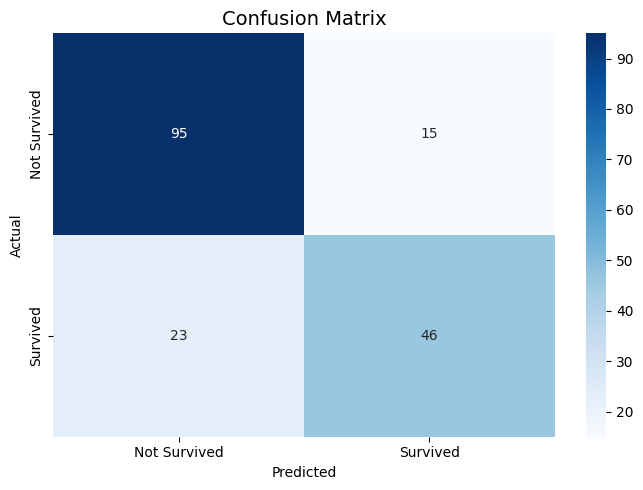

In [43]:
#Heat Map
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

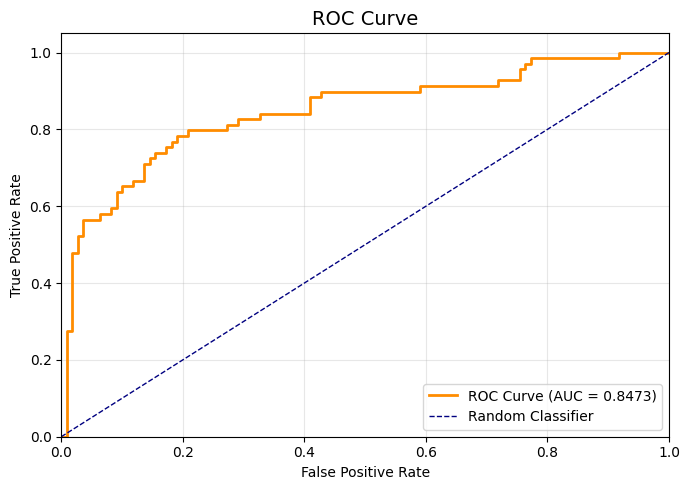

In [44]:
#ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [45]:
#Sample Prediction
results = pd.DataFrame({
    'Actual':      y_test.values,
    'Predicted':   y_pred,
    'Probability': y_prob.round(4)
})

results['Actual Label']    = results['Actual'].map({0: 'Not Survived', 1: 'Survived'})
results['Predicted Label'] = results['Predicted'].map({0: 'Not Survived', 1: 'Survived'})
results['Correct']         = results['Actual'] == results['Predicted']

print('=== Sample Predictions (first 15) ===')
print(results[['Actual Label', 'Predicted Label', 'Probability', 'Correct']].head(15).to_string(index=False))

=== Sample Predictions (first 15) ===
Actual Label Predicted Label  Probability  Correct
Not Survived    Not Survived       0.0779     True
Not Survived    Not Survived       0.0482     True
    Survived    Not Survived       0.1453    False
Not Survived    Not Survived       0.0403     True
    Survived        Survived       0.5833     True
    Survived    Not Survived       0.4699    False
    Survived        Survived       0.7566     True
Not Survived    Not Survived       0.3249     True
Not Survived    Not Survived       0.3741     True
Not Survived    Not Survived       0.1708     True
Not Survived    Not Survived       0.1037     True
Not Survived    Not Survived       0.1010     True
    Survived        Survived       0.5941     True
Not Survived    Not Survived       0.2324     True
Not Survived        Survived       0.6188    False


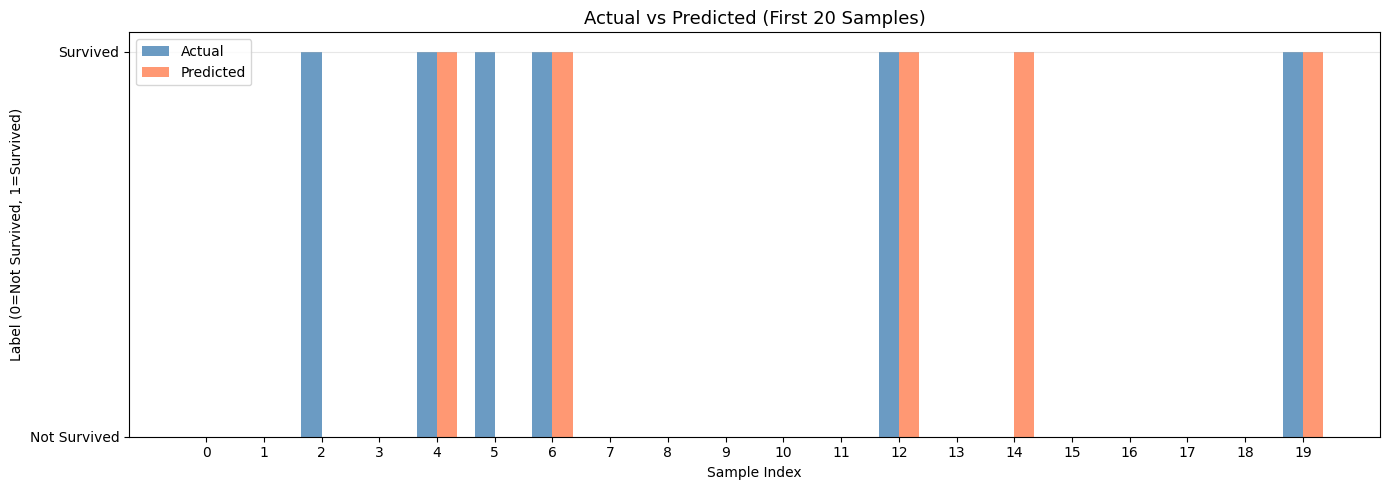

In [46]:
# Visual: Actual vs Predicted bar comparison
sample = results.head(20)

x = np.arange(20)
width = 0.35

plt.figure(figsize=(14,5))
plt.bar(x - width/2, sample['Actual'],    width, label='Actual',    color='steelblue', alpha=0.8)
plt.bar(x + width/2, sample['Predicted'], width, label='Predicted', color='coral',     alpha=0.8)
plt.xlabel('Sample Index')
plt.ylabel('Label (0=Not Survived, 1=Survived)')
plt.title('Actual vs Predicted (First 20 Samples)', fontsize=13)
plt.xticks(x)
plt.yticks([0, 1], ['Not Survived', 'Survived'])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

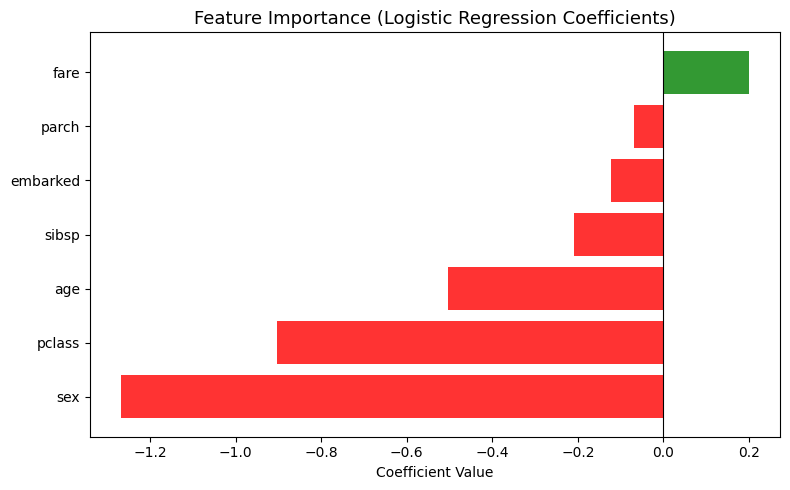


Positive = increases survival probability
Negative = decreases survival probability


In [47]:
#Feature Importance
feature_names = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
coefficients  = model.coef_[0]

feat_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=True)

plt.figure(figsize=(8,5))
colors = ['red' if c < 0 else 'green' for c in feat_df['Coefficient']]
plt.barh(feat_df['Feature'], feat_df['Coefficient'], color=colors, alpha=0.8)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Importance (Logistic Regression Coefficients)', fontsize=13)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print('\nPositive = increases survival probability')
print('Negative = decreases survival probability')

In [48]:
#Summury
print('='*45)
print('         FINAL SUMMARY')
print('='*45)
print(f'  Dataset       : Titanic (891 samples)')
print(f'  Features Used : 7')
print(f'  Train size    : {X_train.shape[0]} samples')
print(f'  Val size      : {X_val.shape[0]} samples')
print(f'  Test size     : {X_test.shape[0]} samples')
print('-'*45)
print(f'  Accuracy      : {accuracy:.4f}')
print(f'  Precision     : {precision:.4f}')
print(f'  Recall        : {recall:.4f}')
print(f'  F1-Score      : {f1:.4f}')
print(f'  AUC           : {auc:.4f}')
print('='*45)

         FINAL SUMMARY
  Dataset       : Titanic (891 samples)
  Features Used : 7
  Train size    : 534 samples
  Val size      : 178 samples
  Test size     : 179 samples
---------------------------------------------
  Accuracy      : 0.7877
  Precision     : 0.7541
  Recall        : 0.6667
  F1-Score      : 0.7077
  AUC           : 0.8473
